In [1]:
# Import libraries for data analysis, visualization, preprocessing, model training, and evaluation.
import io
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Inspect data types, descriptive statistics, numerical/categorical columns, duplicates, and missing values.
uploaded = files.upload()

if not uploaded:
    raise ValueError("Please upload a .csv, .xlsx, or .xls file.")

file_name = next(iter(uploaded))
extension = os.path.splitext(file_name)[1].lower()

if extension == ".csv":
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
elif extension in {".xlsx", ".xls"}:
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
else:
    raise ValueError("Unsupported file type.")

print(f"Loaded file: {file_name}")
display(df.head())

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

Saving HousePricePrediction.xlsx to HousePricePrediction.xlsx
Loaded file: HousePricePrediction.xlsx


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


Dataset shape: (2919, 13)
Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


In [3]:
# Inspect data types, descriptive statistics, numerical/categorical columns, duplicates, and missing values.

df.info()

display(df.describe(include="all").T)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", len(numeric_columns))
print("Categorical features:", len(categorical_columns))
print("Duplicate rows:", df.duplicated().sum())

missing_summary = (
    df.isna()
    .sum()
    .loc[lambda values: values.gt(0)]
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

display(missing_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,2919.0,NaN,NaN,NaN,1459.0,842.787043,0.0,729.5,1459.0,2188.5,2918.0
MSSubClass,2919.0,NaN,NaN,NaN,57.137718,42.517628,20.0,20.0,50.0,70.0,190.0
MSZoning,2915,5,RL,2265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotArea,2919.0,NaN,NaN,NaN,10168.11408,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
LotConfig,2919,5,Inside,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BldgType,2919,5,1Fam,2425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OverallCond,2919.0,NaN,NaN,NaN,5.564577,1.113131,1.0,5.0,5.0,6.0,9.0
YearBuilt,2919.0,NaN,NaN,NaN,1971.312778,30.291442,1872.0,1953.5,1973.0,2001.0,2010.0
YearRemodAdd,2919.0,NaN,NaN,NaN,1984.264474,20.894344,1950.0,1965.0,1993.0,2004.0,2010.0
Exterior1st,2918,15,VinylSd,1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Numerical features: 9
Categorical features: 4
Duplicate rows: 0


,Missing Values
SalePrice,1459
MSZoning,4
Exterior1st,1
BsmtFinSF2,1
TotalBsmtSF,1


Rows with known SalePrice: 1460
Rows with missing SalePrice: 1459
SalePrice skewness: 1.88


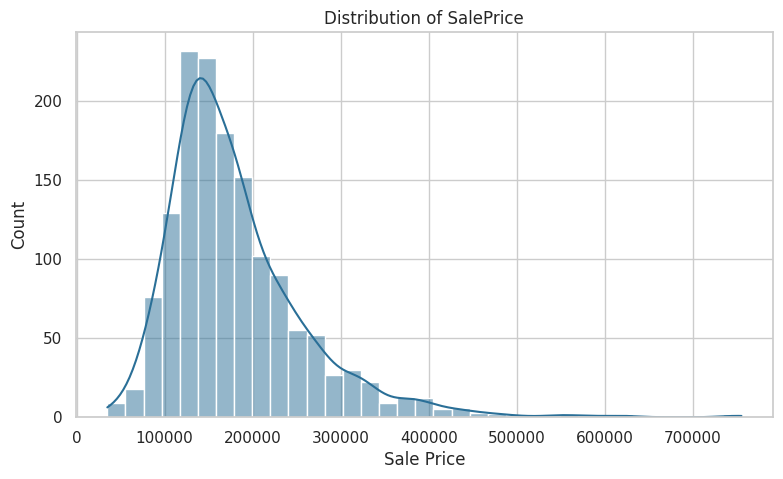

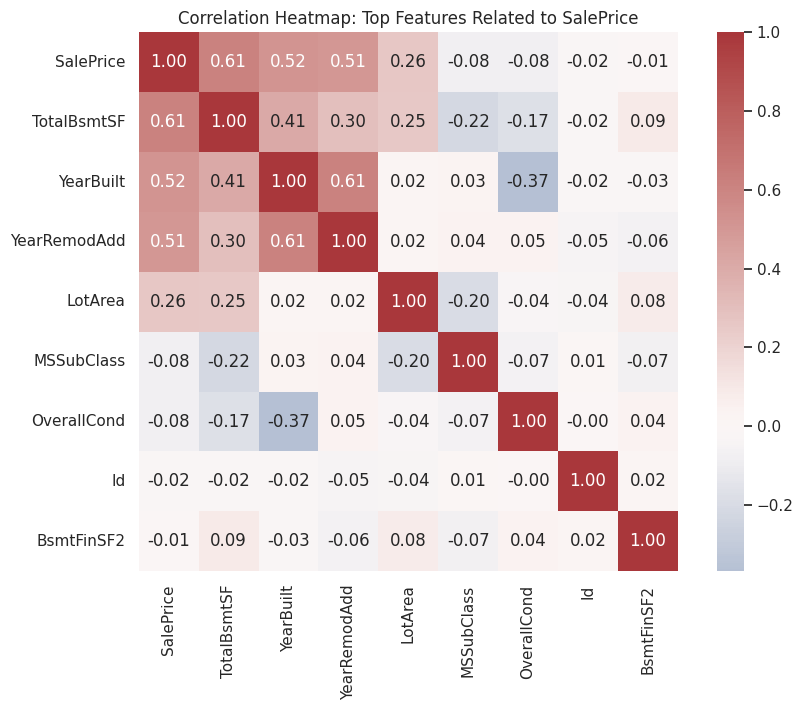

In [4]:
# Analyze the SalePrice distribution and identify numerical features most correlated with house price.

if "SalePrice" not in df.columns:
    raise KeyError("The dataset must contain a 'SalePrice' column.")

observed_target = df["SalePrice"].dropna()

print("Rows with known SalePrice:", len(observed_target))
print("Rows with missing SalePrice:", df["SalePrice"].isna().sum())
print("SalePrice skewness:", round(observed_target.skew(), 2))

plt.figure(figsize=(9, 5))
sns.histplot(observed_target, bins=35, kde=True, color="#2a6f97")
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.show()

numeric_for_eda = df.select_dtypes(include=np.number)

correlations = (
    numeric_for_eda
    .corrwith(df["SalePrice"])
    .abs()
    .sort_values(ascending=False)
)

top_features = correlations.head(12).index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True
)
plt.title("Correlation Heatmap: Top Features Related to SalePrice")
plt.show()

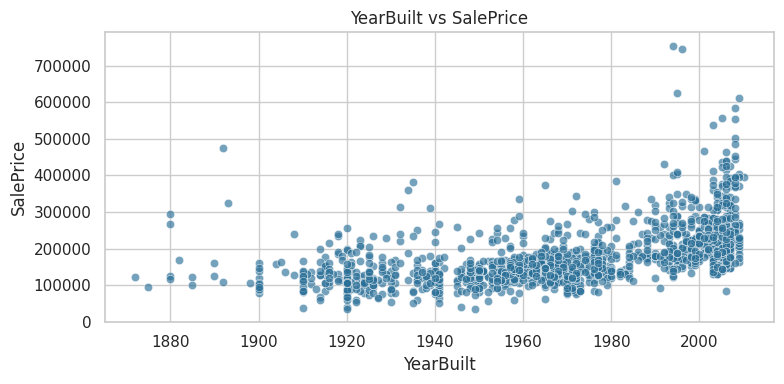

In [5]:
# Visualize how selected numerical features relate to SalePrice when those columns are available.

relationship_features = [
    feature for feature in ["OverallQual", "GrLivArea", "YearBuilt", "GarageCars"]
    if feature in df.columns
]

if relationship_features:
    fig, axes = plt.subplots(
        len(relationship_features),
        1,
        figsize=(8, 4 * len(relationship_features))
    )

    for ax, feature in zip(np.atleast_1d(axes), relationship_features):
        sns.scatterplot(
            data=df,
            x=feature,
            y="SalePrice",
            alpha=0.65,
            color="#2a6f97",
            ax=ax
        )
        ax.set_title(f"{feature} vs SalePrice")

    plt.tight_layout()
    plt.show()

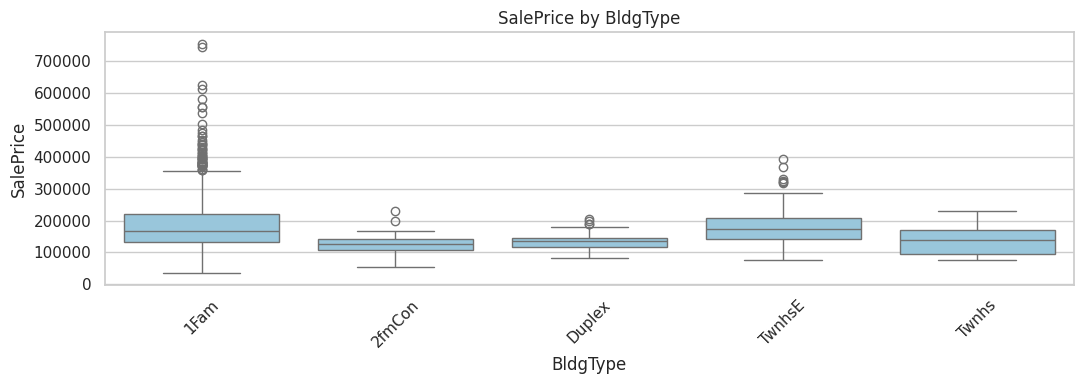

In [6]:
# Compare SalePrice across selected categorical features such as neighborhood and house style.

categorical_candidates = [
    feature for feature in ["Neighborhood", "HouseStyle", "BldgType"]
    if feature in df.columns
]

if categorical_candidates:
    fig, axes = plt.subplots(
        len(categorical_candidates),
        1,
        figsize=(11, 4 * len(categorical_candidates))
    )

    for ax, feature in zip(np.atleast_1d(axes), categorical_candidates):
        plot_data = df[[feature, "SalePrice"]].dropna()

        if plot_data[feature].nunique() > 15:
            top_categories = plot_data[feature].value_counts().head(12).index
            plot_data = plot_data[plot_data[feature].isin(top_categories)]

        sns.boxplot(
            data=plot_data,
            x=feature,
            y="SalePrice",
            color="#8ecae6",
            ax=ax
        )

        ax.tick_params(axis="x", rotation=45)
        ax.set_title(f"SalePrice by {feature}")

    plt.tight_layout()
    plt.show()

In [7]:
# Keep only rows with real SalePrice values
model_df = df.loc[df["SalePrice"].notna()].copy()

print("Rows excluded because SalePrice was missing:", len(df) - len(model_df))

# Remove duplicate labeled rows if any exist
model_df = model_df.drop_duplicates().copy()

# Total square footage
if {"TotalBsmtSF", "1stFlrSF", "2ndFlrSF"}.issubset(model_df.columns):
    model_df["TotalSF"] = model_df[
        ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]
    ].sum(axis=1, min_count=1)

# Total bathrooms
bathroom_columns = ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]

if any(column in model_df.columns for column in bathroom_columns):
    full_baths = sum(
        (model_df[column].fillna(0)
         for column in ["FullBath", "BsmtFullBath"]
         if column in model_df.columns),
        start=0
    )

    half_baths = sum(
        (model_df[column].fillna(0)
         for column in ["HalfBath", "BsmtHalfBath"]
         if column in model_df.columns),
        start=0
    )

    model_df["TotalBathrooms"] = full_baths + 0.5 * half_baths

# House age
if {"YrSold", "YearBuilt"}.issubset(model_df.columns):
    model_df["HouseAge"] = (
        model_df["YrSold"] - model_df["YearBuilt"]
    ).clip(lower=0)

# Years since remodeling
if {"YrSold", "YearRemodAdd"}.issubset(model_df.columns):
    model_df["RemodelAge"] = (
        model_df["YrSold"] - model_df["YearRemodAdd"]
    ).clip(lower=0)

display(model_df.head())

Rows excluded because SalePrice was missing: 1459


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [8]:
# Separate predictor features from SalePrice and split the data into training and testing sets.

X = model_df.drop(columns="SalePrice")
y = model_df["SalePrice"].astype(float)

if "Id" in X.columns:
    X = X.drop(columns="Id")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1168, 11)
Testing shape: (292, 11)


In [9]:
# Impute missing values, encode categorical columns, and scale numerical features for SVR without data leakage.

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

scaled_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

scaled_preprocessor = ColumnTransformer([
    ("num", scaled_numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical model features:", len(numeric_features))
print("Categorical model features:", len(categorical_features))

Numerical model features: 7
Categorical model features: 4


In [10]:
# Train four regression models and compare them using MAE, RMSE, and R2 metrics.

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Support Vector Regression": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", SVR(C=100, epsilon=0.1))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ])
}

results = []
test_predictions = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    test_predictions[model_name] = predictions

    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": root_mean_squared_error(y_test, predictions),
        "R²": r2_score(y_test, predictions)
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

display(
    results_df.style.format({
        "MAE": "${:,.0f}",
        "RMSE": "${:,.0f}",
        "R²": "{:.3f}"
    })
)

,Model,MAE,RMSE,R²
0,Gradient Boosting,"$23,509","$35,950",0.832
1,Random Forest,"$22,919","$37,011",0.821
2,Linear Regression,"$34,123","$54,023",0.620
3,Support Vector Regression,"$54,212","$83,864",0.083


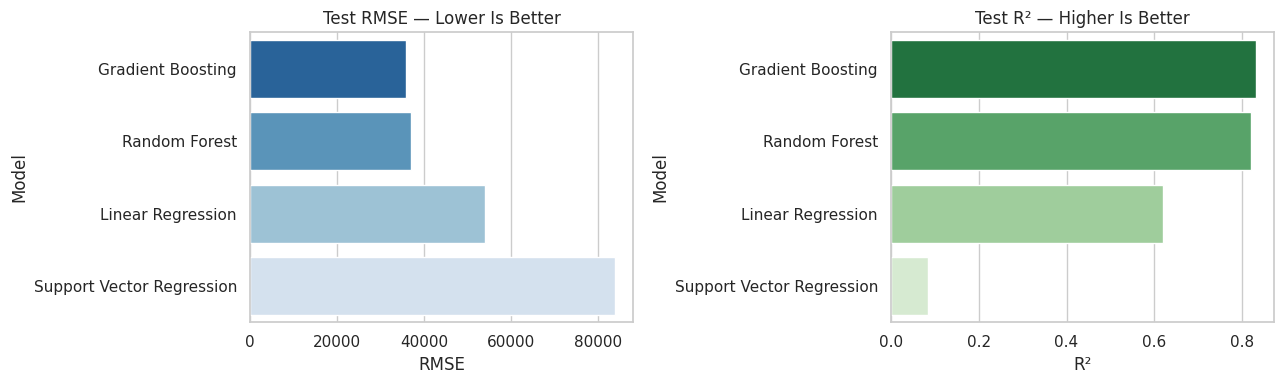

In [11]:
# Visualize RMSE and R2 scores to compare the performance of all models.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model",
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Test RMSE — Lower Is Better")

sns.barplot(
    data=results_df,
    x="R²",
    y="Model",
    palette="Greens_r",
    ax=axes[1]
)
axes[1].set_title("Test R² — Higher Is Better")

plt.tight_layout()
plt.show()

In [12]:
# Perform 5-fold cross-validation on the strongest models to check performance stability.

cv_rows = []

for model_name in results_df["Model"].head(3):
    scores = cross_validate(
        models[model_name],
        X_train,
        y_train,
        cv=5,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV RMSE")

display(
    cv_results_df.style.format({
        "CV MAE": "${:,.0f}",
        "CV RMSE": "${:,.0f}",
        "CV R²": "{:.3f}"
    })
)

,Model,CV MAE,CV RMSE,CV R²
1,Random Forest,"$23,293","$37,966",0.755
0,Gradient Boosting,"$23,445","$38,303",0.749
2,Linear Regression,"$32,415","$49,510",0.585


Best model: Gradient Boosting
MAE: $23,509
RMSE: $35,950
R²: 0.832


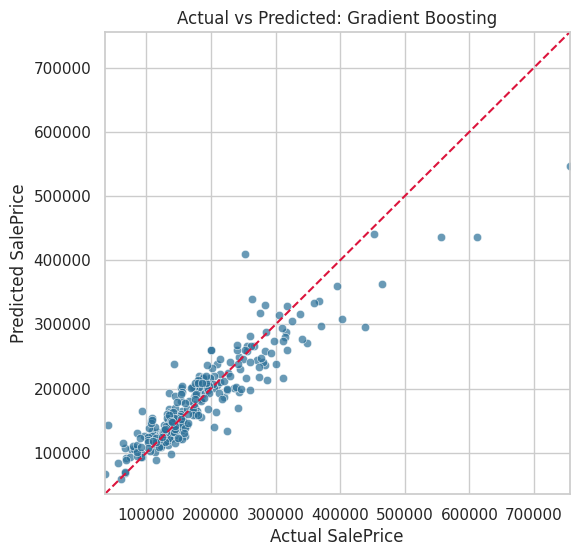

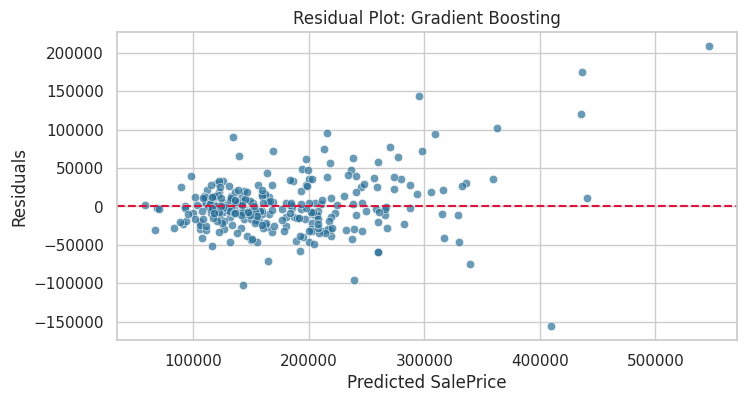

In [13]:
# Select the best model and visualize actual versus predicted prices and residual errors.
best_model_name = results_df.loc[0, "Model"]
best_predictions = test_predictions[best_model_name]
best_metrics = results_df.iloc[0]

print("Best model:", best_model_name)
print(f"MAE: ${best_metrics['MAE']:,.0f}")
print(f"RMSE: ${best_metrics['RMSE']:,.0f}")
print(f"R²: {best_metrics['R²']:.3f}")

plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.7,
    color="#2a6f97"
)

limits = [
    min(y_test.min(), best_predictions.min()),
    max(y_test.max(), best_predictions.max())
]

plt.plot(limits, limits, "--", color="crimson")
plt.xlim(limits)
plt.ylim(limits)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.show()

residuals = y_test - best_predictions

plt.figure(figsize=(8, 4))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.7,
    color="#2a6f97"
)

plt.axhline(0, color="crimson", linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {best_model_name}")
plt.show()

,Feature,Importance
6,num__TotalBsmtSF,0.368091
3,num__YearBuilt,0.277011
1,num__LotArea,0.134953
0,num__MSSubClass,0.114712
4,num__YearRemodAdd,0.049748
2,num__OverallCond,0.022294
35,cat__Exterior1st_Wd Sdng,0.008764
25,cat__Exterior1st_BrkFace,0.007414
11,cat__MSZoning_RM,0.004262
19,cat__BldgType_Duplex,0.003400


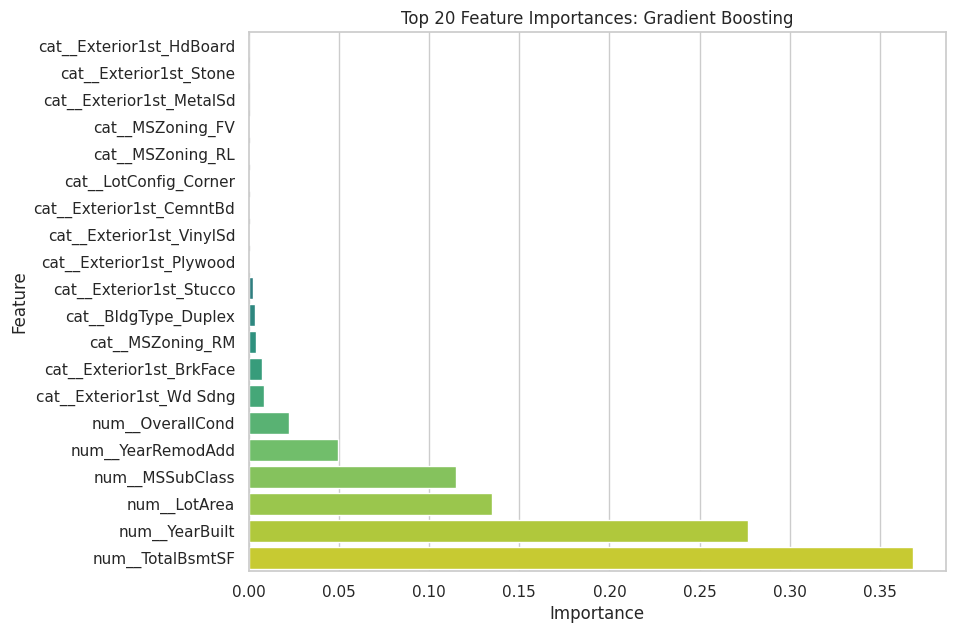

In [14]:
# Identify the most important features from the strongest tree-based regression model.

tree_model_names = ["Random Forest", "Gradient Boosting"]

importance_model_name = next(
    model_name
    for model_name in results_df["Model"]
    if model_name in tree_model_names
)

importance_pipeline = models[importance_model_name]

feature_names = (
    importance_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    importance_pipeline
    .named_steps["model"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(20)
)

display(importance_df)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=importance_df.sort_values("Importance"),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(f"Top 20 Feature Importances: {importance_model_name}")
plt.show()

In [15]:
# Display actual prices, predicted prices, and absolute errors for sample test records.

sample_predictions = pd.DataFrame({
    "Actual Price": y_test.to_numpy(),
    "Predicted Price": best_predictions
})

sample_predictions["Absolute Error"] = (
    sample_predictions["Actual Price"] -
    sample_predictions["Predicted Price"]
).abs()

display(
    sample_predictions.head(10).style.format({
        "Actual Price": "${:,.0f}",
        "Predicted Price": "${:,.0f}",
        "Absolute Error": "${:,.0f}"
    })
)

,Actual Price,Predicted Price,Absolute Error
0,"$154,500","$145,203","$9,297"
1,"$325,000","$305,608","$19,392"
2,"$115,000","$110,048","$4,952"
3,"$159,000","$125,861","$33,139"
4,"$315,500","$287,391","$28,109"
5,"$75,500","$105,355","$29,855"
6,"$311,500","$215,871","$95,629"
7,"$146,000","$132,691","$13,309"
8,"$84,500","$105,355","$20,855"
9,"$135,500","$168,208","$32,708"
